In [2]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 8.0 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 10.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.0/8.3 MB 10.4 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 10.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.5 MB 11.2 MB/s eta 0:00:01
   -------------- ------------------------- 4.5/12.5 MB 11.3 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.5 MB 11.2 MB/s eta 0:00:01
   ------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import csv
import sqlalchemy as db
import matplotlib.pyplot as plt

In [84]:
engine = db.create_engine("sqlite:///titanic2.db")

metadata = db.MetaData()

In [85]:
passengers = db.Table(
    'Passengers', metadata,

    db.Column('id', db.Integer, primary_key=True),

    db.Column('passenger_id', db.Integer),
    db.Column('survived', db.Integer),
    db.Column('sex', db.Integer),

    db.Column('age', db.Float),
    db.Column('fare', db.Float),

    db.Column('pclass_1', db.Integer),
    db.Column('pclass_2', db.Integer),
    db.Column('pclass_3', db.Integer),

    db.Column('family_size', db.Float),

    db.Column('title_1', db.Integer),
    db.Column('title_2', db.Integer),
    db.Column('title_3', db.Integer),
    db.Column('title_4', db.Integer),

    db.Column('emb_1', db.Integer),
    db.Column('emb_2', db.Integer),
    db.Column('emb_3', db.Integer)
)

In [86]:
metadata.create_all(engine)

In [87]:
conn = engine.connect()

In [88]:
with open("train_data.csv", newline='', encoding='utf-8') as file:

    reader = csv.DictReader(file)

    for row in reader:

        query = passengers.insert().values(

            passenger_id=int(row["PassengerId"]),
            survived=int(row["Survived"]),
            sex=int(row["Sex"]),

            age=float(row["Age"]),
            fare=float(row["Fare"]),

            pclass_1=int(row["Pclass_1"]),
            pclass_2=int(row["Pclass_2"]),
            pclass_3=int(row["Pclass_3"]),

            family_size=float(row["Family_size"]),

            title_1=int(row["Title_1"]),
            title_2=int(row["Title_2"]),
            title_3=int(row["Title_3"]),
            title_4=int(row["Title_4"]),

            emb_1=int(row["Emb_1"]),
            emb_2=int(row["Emb_2"]),
            emb_3=int(row["Emb_3"])
        )

        conn.execute(query)

In [89]:
result = conn.execute(db.text('SELECT * FROM passengers')).fetchall()
print(len(result))

792


In [90]:
conn.execute(db.text('SELECT * FROM passengers')).fetchall()

[(1, 1, 0, 1, 0.275, 0.014151057562208049, 0, 0, 1, 0.1, 1, 0, 0, 0, 0, 0, 1),
 (2, 2, 1, 0, 0.475, 0.13913573538264068, 1, 0, 0, 0.1, 1, 0, 0, 0, 1, 0, 0),
 (3, 3, 1, 0, 0.325, 0.015468569817999833, 0, 0, 1, 0.0, 0, 0, 0, 1, 0, 0, 1),
 (4, 4, 1, 0, 0.4375, 0.10364429745562033, 1, 0, 0, 0.1, 1, 0, 0, 0, 0, 0, 1),
 (5, 5, 0, 1, 0.4375, 0.015712553569072387, 0, 0, 1, 0.0, 1, 0, 0, 0, 0, 0, 1),
 (6, 6, 0, 1, 0.35, 0.01650950209357577, 0, 0, 1, 0.0, 1, 0, 0, 0, 0, 1, 0),
 (7, 7, 0, 1, 0.675, 0.10122885832000206, 1, 0, 0, 0.0, 1, 0, 0, 0, 0, 0, 1),
 (8, 8, 0, 1, 0.025, 0.04113566043083236, 0, 0, 1, 0.4, 0, 0, 1, 0, 0, 0, 1),
 (9, 9, 1, 0, 0.3375, 0.021730754366528396, 0, 0, 1, 0.2, 1, 0, 0, 0, 0, 0, 1),
 (10, 10, 1, 0, 0.175, 0.058694292654020104, 0, 1, 0, 0.1, 1, 0, 0, 0, 1, 0, 0),
 (11, 11, 1, 0, 0.05, 0.03259622914329302, 0, 0, 1, 0.2, 0, 0, 0, 1, 0, 0, 1),
 (12, 12, 1, 0, 0.725, 0.051822148727810165, 1, 0, 0, 0.0, 0, 0, 0, 1, 0, 0, 1),
 (13, 13, 0, 1, 0.25, 0.015712553569072387, 0, 0, 1

In [91]:
all_survived = conn.execute(db.text('SELECT count(survived) FROM passengers WHERE survived = 1')).scalar()
all_survived

306

In [92]:
all_women = conn.execute(db.text('SELECT count(sex) FROM passengers WHERE sex = 0')).scalar()
all_women

279

In [93]:
women = conn.execute(db.text('SELECT count(sex) FROM passengers WHERE sex = 0 AND survived = 1')).scalar()
women

209

In [94]:
perc_of_women_survived = round(women / all_women * 100)
perc_of_women_survived

75

In [95]:
all_men = conn.execute(db.text('SELECT count(sex) FROM passengers WHERE sex = 1')).scalar()
all_men

513

In [96]:
men = conn.execute(db.text('SELECT count(sex) FROM passengers WHERE sex = 1 AND survived = 1')).scalar()
men

97

In [97]:
perc_of_men_survived = round(men / all_men * 100)
perc_of_men_survived

19

In [98]:
perc_of_women_survived_from_all_survived = round((women / all_survived) * 100)
perc_of_women_survived_from_all_survived

68

In [99]:
perc_of_men_survived_from_all_survived = round((men / all_survived) * 100)
perc_of_men_survived_from_all_survived

32

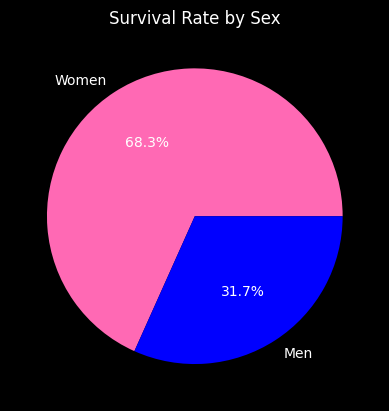

In [119]:
y = [women, men]
mylabels = ['Women', 'Men']
mycolors = ["hotpink", "b"]
plt.title("Survival Rate by Sex")
plt.pie(y, labels = mylabels,colors = mycolors, autopct='%1.1f%%')
plt.show()

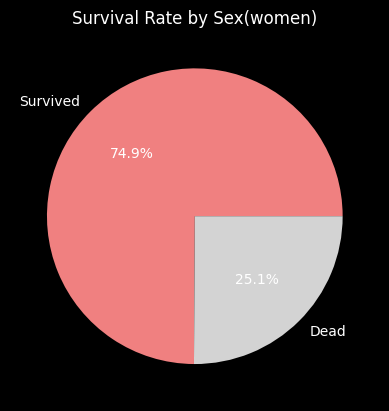

In [120]:
y = [women, all_women - women]
mylabels = ['Survived', 'Dead']
mycolors = ["#f08080", "#D3D3D3"]
plt.title("Survival Rate by Sex(women)")
plt.pie(y, labels = mylabels,colors = mycolors, autopct='%1.1f%%')
plt.show()

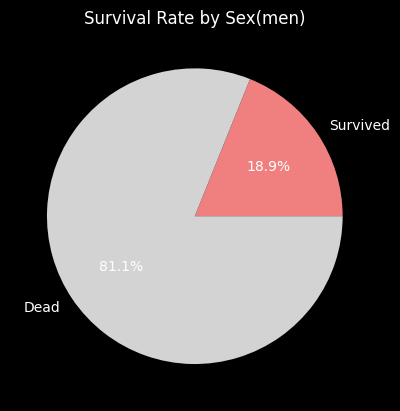

In [121]:
y = [men, all_men - men]
mylabels = ['Survived', 'Dead']
mycolors = ["#f08080", "#D3D3D3"]
plt.title("Survival Rate by Sex(men)")
plt.pie(y, labels = mylabels,colors = mycolors, autopct='%1.1f%%')
plt.show()

Среди 306 выживших 209 женщин и 97 мужчин, что в процентном соотношении составляет 68/32

Среди 279 женщин на борту выжило 209, что составляет 75%

Среди 513 мужчин на борту выжило 97, что составляет 19%

In [100]:
age_groups = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
COUNT(*)
FROM Passengers
GROUP BY age_group
''')).fetchall()
print(age_groups)

[('Adult', 492), ('Child', 61), ('Old', 239)]


In [101]:
age_groups_survived = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
COUNT(*)
FROM Passengers
WHERE survived = 1
GROUP BY age_group
''')).fetchall()
print(age_groups_survived)

[('Adult', 173), ('Child', 37), ('Old', 96)]


In [102]:
age_groups_survived_perc = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
ROUND(SUM(survived) * 100 / COUNT(*)) AS survival_percent
FROM Passengers
GROUP BY age_group
''')).fetchall()
print(age_groups_survived_perc)

[('Adult', 35.0), ('Child', 60.0), ('Old', 40.0)]


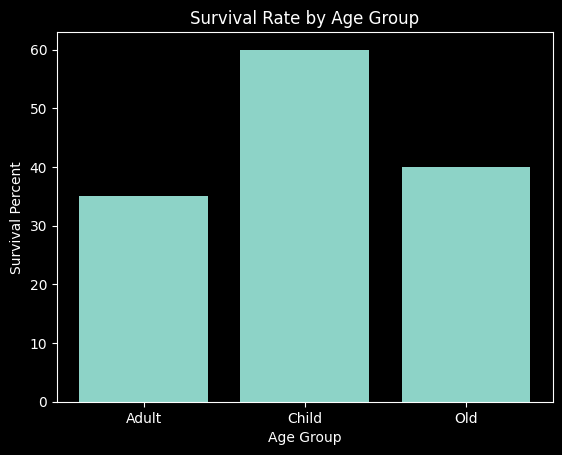

In [109]:
x = []
y = []

for row in age_groups_survived_perc:
    x.append(row[0])
    y.append(row[1])

plt.bar(x, y)

plt.title("Survival Rate by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Survival Percent")

plt.show()

Информация по возрастным группам:
Child: из 61 человека выжило 37, что составляет 60%
Adult: из 492 человек выжило 173, что составляет 35%
Old: из 239 человек выжило 96, что составляет 40%

In [103]:
age_groups_women = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
COUNT(*)
FROM Passengers
WHERE sex = 0
GROUP BY age_group
''')).fetchall()
print(age_groups_women)

[('Adult', 167), ('Child', 32), ('Old', 80)]


In [104]:
age_groups_women_survived = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
COUNT(*)
FROM Passengers
WHERE sex = 0 AND survived = 1
GROUP BY age_group
''')).fetchall()
print(age_groups_women_survived)

[('Adult', 122), ('Child', 21), ('Old', 66)]


In [105]:
age_groups_women_survived_percent = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
ROUND(SUM(survived) * 100 / COUNT(*)) AS survival_percent
FROM Passengers
WHERE sex = 0
GROUP BY age_group
''')).fetchall()
print(age_groups_women_survived_percent)

[('Adult', 73.0), ('Child', 65.0), ('Old', 82.0)]


In [106]:
age_groups_men = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
COUNT(*)
FROM Passengers
WHERE sex = 1
GROUP BY age_group
''')).fetchall()
print(age_groups_men)

[('Adult', 325), ('Child', 29), ('Old', 159)]


In [107]:
age_groups_men_survived = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
COUNT(*)
FROM Passengers
WHERE sex = 1 AND survived = 1
GROUP BY age_group
''')).fetchall()
print(age_groups_men_survived)

[('Adult', 51), ('Child', 16), ('Old', 30)]


In [108]:
age_groups_men_survived_percent = conn.execute(db.text('''
SELECT
CASE
WHEN ROUND(age * 100) < 18 THEN 'Child'
WHEN ROUND(age * 100) > 17 AND ROUND(age * 100) <= 40 THEN 'Adult'
ELSE 'Old'
END AS age_group,
ROUND(SUM(survived) * 100 / COUNT(*)) AS survival_percent
FROM Passengers
WHERE sex = 1
GROUP BY age_group
''')).fetchall()
print(age_groups_men_survived_percent)

[('Adult', 15.0), ('Child', 55.0), ('Old', 18.0)]


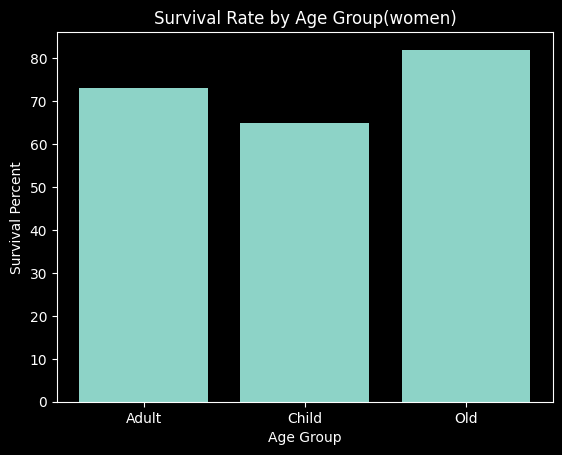

In [110]:
x = []
y = []

for row in age_groups_women_survived_percent:
    x.append(row[0])
    y.append(row[1])

plt.bar(x, y)

plt.title("Survival Rate by Age Group(women)")

plt.xlabel("Age Group")
plt.ylabel("Survival Percent")

plt.show()

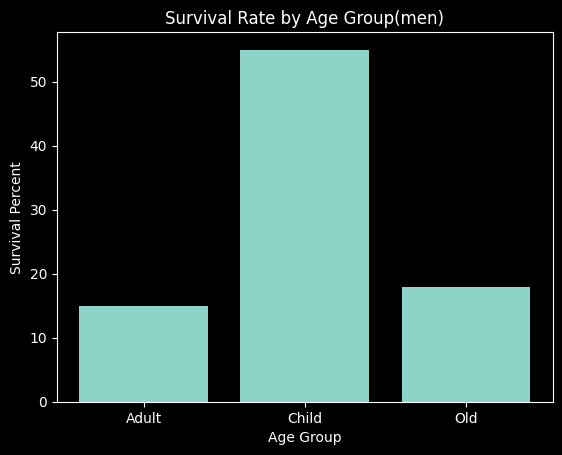

In [111]:
x = []
y = []

for row in age_groups_men_survived_percent:
    x.append(row[0])
    y.append(row[1])

plt.bar(x, y)

plt.title("Survival Rate by Age Group(men)")

plt.xlabel("Age Group")
plt.ylabel("Survival Percent")

plt.show()

Информация по возрастным группам и полу:
Child:
&nbsp;&nbsp;&nbsp;&nbsp;ж: из 32 человека выжило 21, что составляет 65%
&nbsp;&nbsp;&nbsp;&nbsp;м: из 29 человека выжило 16, что составляет 55%
Adult:
&nbsp;&nbsp;&nbsp;&nbsp;ж: из 167 человека выжило 122, что составляет 33%
&nbsp;&nbsp;&nbsp;&nbsp;м: из 325 человека выжило 51, что составляет 15%
Old:
&nbsp;&nbsp;&nbsp;&nbsp;ж: из 80 человека выжило 66, что составляет 82%
&nbsp;&nbsp;&nbsp;&nbsp;м: из 159 человека выжило 30, что составляет 18%